In [1]:
import os

from pathlib import Path

import matplotlib.pyplot as plt

import h5py

import numpy as np

from structure_tensor import eig_special_3d, structure_tensor_3d, anisotropy


In [2]:
file_path = Path("../data/BIIAX_196(245)_02/BIIAX_196(245)_02_2026-04-17_103446/tomo-A/BIIAX_196(245)_02_tomo-A_recon_test512-2.5.val.vec.h5")
file_path_raw = Path("../data/BIIAX_196(245)_02/BIIAX_196(245)_02_2026-04-17_103446/tomo-A/BIIAX_196(245)_02_tomo-A_recon_test512.h5")

In [3]:
with h5py.File(file_path_raw, "r") as f:
    raw = f["volume"][:]

In [4]:
with h5py.File(file_path, "r") as f:
    vec = f["vec"][:]
    eig = f["eig"][:]

In [5]:
from scipy.ndimage import gaussian_filter

# set to match your structure tensor parameters
sigma = 1.6 # same sigma used in structure_tensor_3d
truncate = 4.0

raw_smooth = gaussian_filter(raw.astype(np.float32), sigma=sigma, truncate=truncate)
print(f"Smoothed raw: {raw_smooth.shape}  sigma={sigma}")


Smoothed raw: (512, 512, 512)  sigma=1.6


PCA kept 4 components  (96.7% variance)


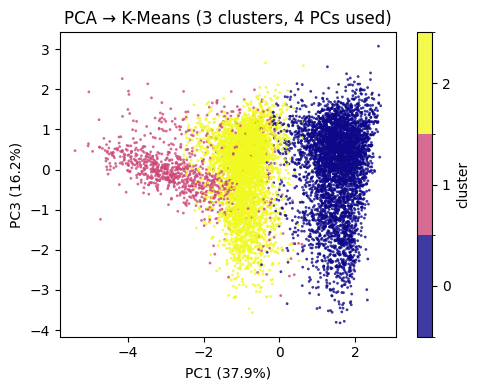

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors

# helper — same feature layout used in both fit and predict steps
def extract_features(eig_s, vec_s, raw_s):
    fa = anisotropy(eig_s, kind="fa").ravel().astype(np.float32)
    cs = anisotropy(eig_s, kind="spherical").ravel().astype(np.float32)
    vx, vy, vz = vec_s[0].ravel(), vec_s[1].ravel(), vec_s[2].ravel()
    return np.column_stack([fa, cs, vx*vx, vy*vy, vz*vz,
                             raw_s.ravel().astype(np.float32)])

# --- fit on a random subsample (no full-volume matrix) ---
n_sample  = 200_000
rng       = np.random.default_rng(0)
flat_idx  = rng.choice(raw.size, size=n_sample, replace=False)
zi = flat_idx // (raw.shape[1] * raw.shape[2])
yi = (flat_idx % (raw.shape[1] * raw.shape[2])) // raw.shape[2]
xi = flat_idx % raw.shape[2]

X_sample = extract_features(eig[:, zi, yi, xi],
                             vec[:, zi, yi, xi],
                             raw_smooth[zi, yi, xi])

scaler   = StandardScaler().fit(X_sample)
Xs       = scaler.transform(X_sample)

pca_full = PCA(n_components=0.95).fit(Xs)
n_pcs    = pca_full.n_components_
ev       = pca_full.explained_variance_ratio_
print(f"PCA kept {n_pcs} components  ({ev.cumsum()[-1]:.1%} variance)")

Xpca = pca_full.transform(Xs)

n_clusters = 3
km     = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
labels = km.fit_predict(Xpca)

# 2D scatter: PC1 vs PC2  —  discrete colorbar
cmap = plt.get_cmap("plasma", n_clusters)
norm = mcolors.BoundaryNorm(boundaries=range(n_clusters + 1), ncolors=n_clusters)

fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(Xpca[::20, 0], Xpca[::20, 2],
                c=labels[::20], cmap=cmap, norm=norm, s=4, alpha=0.8, linewidths=0)
ax.set_xlabel(f"PC1 ({ev[0]:.1%})")
ax.set_ylabel(f"PC3 ({ev[2]:.1%})")
ax.set_title(f"PCA → K-Means ({n_clusters} clusters, {n_pcs} PCs used)")
cb = fig.colorbar(sc, ax=ax, ticks=np.arange(n_clusters) + 0.5, label="cluster")
cb.set_ticklabels(range(n_clusters))``
plt.tight_layout()
plt.savefig("pca_kmeans_scatter.pdf", dpi=300)
plt.show()

In [ ]:
import matplotlib.colors as mcolors
from scipy.ndimage import binary_opening, grey_dilation, generate_binary_structure, gaussian_filter

batch_size = 32    # Z-slices per batch

# --- per-cluster morpho control ---
# n_iters=0 → skip cleanup for that cluster
# n_iters=k → removes isolated fragments smaller than ~4·k³ voxels
morph_iters = {
    0: 4,
    1: 4,
    2: 4,   # e.g. background — skip
}

gauss_sigma = 2.0   # boundary smoothing sigma (voxels); 0 = off
                    # higher → smoother edges but more blurring

struct  = generate_binary_structure(3, 1)
morph_o = max(morph_iters.values()) + 1
gauss_o = int(np.ceil(4 * gauss_sigma)) if gauss_sigma > 0 else 0
overlap = morph_o + gauss_o
D       = raw.shape[0]

# --- batched predict ---
labels_full = np.empty(raw.shape, dtype=np.uint8)
for z0 in range(0, D, batch_size):
    z1   = min(z0 + batch_size, D)
    X_b  = extract_features(eig[:, z0:z1], vec[:, z0:z1], raw_smooth[z0:z1])
    pred = km.predict(pca_full.transform(scaler.transform(X_b)))
    labels_full[z0:z1] = pred.reshape(z1 - z0, *raw.shape[1:])
    print(f"  predict  {z0:4d}–{z1:4d}", end="\r")
print("predict done.         ")

# --- batched morpho + boundary smoothing ---
cleaned = np.empty_like(labels_full)
for z0 in range(0, D, batch_size):
    z1  = min(z0 + batch_size, D)
    z0h = max(0, z0 - overlap)
    z1h = min(D,  z1 + overlap)

    batch   = labels_full[z0h:z1h].astype(np.int16)
    clean_b = batch.copy()

    # step 1: binary opening per cluster
    for k in range(n_clusters):
        iters = morph_iters.get(k, 0)
        if iters == 0:
            continue
        mask   = batch == k
        opened = binary_opening(mask, structure=struct, iterations=iters)
        clean_b[mask & ~opened] = -1

    for _ in range(overlap + 4):
        gap = clean_b == -1
        if not gap.any():
            break
        grown = grey_dilation(clean_b, size=3)
        clean_b[gap] = grown[gap]

    # step 2: Gaussian soft-voting → smooth boundaries
    if gauss_sigma > 0:
        scores = np.stack([
            gaussian_filter((clean_b == k).astype(np.float32), sigma=gauss_sigma)
            for k in range(n_clusters)
        ], axis=0)                          # (n_clusters, Z, Y, X)
        clean_b = scores.argmax(axis=0).astype(np.int16)

    lo = z0 - z0h
    hi = z1h - z1
    cleaned[z0:z1] = clean_b[lo : len(clean_b) - hi if hi else None]
    print(f"  morpho   {z0:4d}–{z1:4d}", end="\r")
print("morpho done.          ")

changed_frac = (cleaned != labels_full).mean() * 100
print(f"Changed {changed_frac:.2f} % of voxels after cleanup")

# --- display mid slice ---
mid      = D // 2
raw_norm = raw[mid].astype(np.float32)
raw_norm = (raw_norm - raw_norm.min()) / (raw_norm.max() - raw_norm.min() + 1e-12)
cmap_c   = plt.get_cmap("tab10", n_clusters)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(raw_norm, cmap="gray", interpolation="nearest")
axes[0].set_title("Raw (mid slice)"); axes[0].axis("off")

axes[1].imshow(labels_full[mid], cmap=cmap_c, vmin=0, vmax=n_clusters - 1,
               interpolation="nearest")
axes[1].set_title("Raw clusters"); axes[1].axis("off")

axes[2].imshow(cleaned[mid], cmap=cmap_c, vmin=0, vmax=n_clusters - 1,
               interpolation="nearest")
axes[2].set_title(f"Cleaned (σ={gauss_sigma})"); axes[2].axis("off")
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_c,
             norm=mcolors.BoundaryNorm(range(n_clusters + 1), n_clusters)),
             ax=axes[2], ticks=np.arange(n_clusters) + 0.5,
             format=plt.FuncFormatter(lambda x, _: f"{int(x)}"))

axes[3].imshow(raw_norm, cmap="gray", interpolation="nearest")
axes[3].imshow(cleaned[mid], cmap=cmap_c, vmin=0, vmax=n_clusters - 1,
               alpha=0.4, interpolation="nearest")
axes[3].set_title("Overlay (cleaned)"); axes[3].axis("off")

plt.suptitle(f"PCA → K-Means  |  slice z={mid}  |  {n_clusters} clusters", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
import nrrd

# --- remap labels: old 1→0, old 0→1, old 2→2 ---
remap = {0: 1, 1: 0, 2: 2}
lut   = np.arange(n_clusters, dtype=np.uint8)
for old, new in remap.items():
    lut[old] = new
seg_remapped = lut[cleaned]

# --- output paths ---
out_raw = file_path_raw.with_suffix(".nrrd")
out_seg = file_path_raw.with_name(file_path_raw.stem + ".seg.nrrd")
out_vec = file_path_raw.with_name(file_path_raw.stem + ".vec.nrrd")

voxel_size_mm = 1.0   # adjust to your true voxel size

def scalar_header(dtype_str):
    return {
        "type":             dtype_str,
        "dimension":        3,
        "space":            "left-posterior-superior",
        "space directions": np.diag([voxel_size_mm]*3).tolist(),
        "kinds":            ["domain", "domain", "domain"],
        "endian":           "little",
        "encoding":         "gzip",
    }

nrrd.write(str(out_raw), raw, header=scalar_header(str(raw.dtype)))
print(f"Saved raw  → {out_raw}")

nrrd.write(str(out_seg), seg_remapped, header=scalar_header("uint8"))
print(f"Saved seg  → {out_seg}  (labels: {remap})")


In [ ]:
from structure_tensor.post_processing import align_direction

# --- apply segmentation mask + per-cluster sign alignment ---
# seg 0 → zero vector (cancel)
# seg 1 → keep original vec, align sign so vx ≥ 0
# seg 2 → keep original vec, align sign so vz ≥ 0

vec_masked = np.zeros_like(vec)

for label, axes in [ (2, ("z",)),(1, ("x",))]:
    mask = seg_remapped == label          # (D, H, W) bool
    v_seg = vec[:, mask]                  # (3, N) — voxels in this segment
    v_aligned = align_direction(v_seg, axes=axes)
    vec_masked[:, mask] = v_aligned



# --- quick mid-slice check ---
mid = seg_remapped.shape[0] // 2
fig, axes_plot = plt.subplots(1, 3, figsize=(15, 5))
for ax, comp, lbl in zip(axes_plot, [0, 1, 2], ["vx", "vy", "vz"]):
    ax.imshow(vec_masked[comp, mid], cmap="RdBu", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"{lbl} (mid slice)"); ax.axis("off")
plt.suptitle("Masked + aligned vec field  (seg0=zero, seg1→+x, seg2→+z)")
plt.tight_layout()
plt.show()


In [ ]:
def edge_aware_smooth_vec(v, iters=2, sigma_theta_deg=24.0, eps=1e-12):
    """
    Edge-aware smoothing for a line field (v ≡ -v). Preserves sharp 90° jumps.
    v : (3, Z, Y, X)
    """
    v = v.copy().astype(np.float32)
    sigma_theta = np.deg2rad(sigma_theta_deg)

    def normed(x):
        n = np.linalg.norm(x, axis=0, keepdims=True)
        return x / np.maximum(n, eps)

    v = normed(v)
    shifts = [(+1,0,0),(-1,0,0),(0,+1,0),(0,-1,0),(0,0,+1),(0,0,-1)]

    for it in range(iters):
        acc  = np.zeros_like(v)
        wsum = np.zeros(v.shape[1:], dtype=v.dtype)

        for dx, dy, dz in shifts:
            vn    = np.roll(v, shift=(dx, dy, dz), axis=(1, 2, 3))
            c     = np.clip(np.abs(np.sum(v * vn, axis=0)), 0.0, 1.0)
            theta = np.arccos(c)
            w     = np.exp(-(theta**2) / (2 * sigma_theta**2)).astype(v.dtype)
            acc  += vn * w[None, ...]
            wsum += w

        acc  += v;  wsum += 1.0
        v     = normed(acc / wsum[None, ...])
        print(f"  smooth iter {it+1}/{iters}", end="\r")

    print("edge-aware smooth done.")
    return v

# apply to vec_masked — only smooths non-zero regions (seg 1 & 2)
vec_masked = edge_aware_smooth_vec(vec_masked, iters=2, sigma_theta_deg=24.0)




In [ ]:
from structure_tensor.xdmf_io import write_xdmf_for_h5

out_h5 = file_path_raw.with_name(file_path_raw.stem + ".results.h5")

with h5py.File(out_h5, "w") as f:
    f.create_dataset("volume",      data=raw,           compression="gzip")
    f.create_dataset("seg",         data=seg_remapped,  compression="gzip")
    f.create_dataset("vec_masked",  data=vec_masked.astype(np.float32), compression="gzip")

xmf_path = write_xdmf_for_h5(
    out_h5,
    keys=["volume", "seg", "vec_masked"],
    grid_key="volume",
    spacing_xyz=(voxel_size_mm,) * 3,
    attribute_type_override={"seg": "Scalar"},
)

print(f"Saved H5   → {out_h5}")
print(f"Saved XDMF → {xmf_path}")
